In [3]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [4]:
data_path = "../data/Heart_failure_clinical_records_dataset.csv"  
df = pd.read_csv(data_path)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
# rename coloumns
df = df.rename(columns={
    'duration': 'time',
    'DEATH_EVENT': 'event'
})

In [15]:
# Step 1 — Kaplan–Meier Survival Curve (Overall)

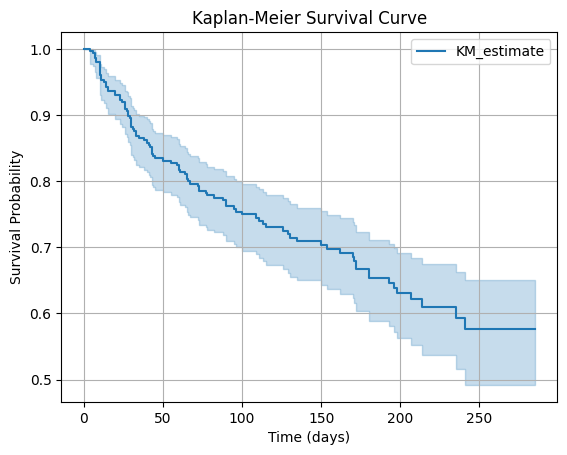

In [12]:
kmf = KaplanMeierFitter()

kmf.fit(durations=df['time'], event_observed=df['event'])

kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid()
plt.show()

In [ ]:
### Above graph gives the overall survival probability over time.


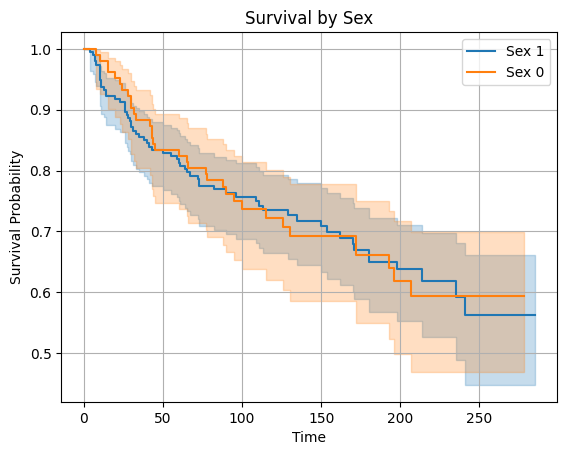

In [ ]:
# Step 2 — Survival Curve by Important Clinical Variables
##--- Survival by Sex ----
kmf = KaplanMeierFitter()

for group in df["sex"].unique():

    subset = df[df["sex"] == group]

    kmf.fit(
        subset["time"],
        subset["event"],
        label=f"Sex {group}"
    )

    kmf.plot_survival_function()

plt.title("Survival by Sex")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid()
plt.show()

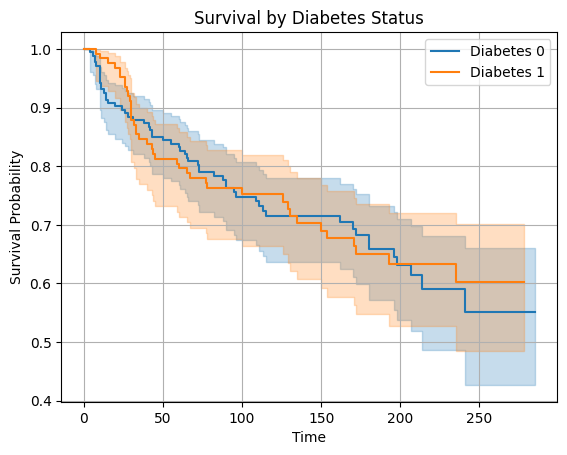

In [19]:
##--- Survival by Diabetes Status ----
kmf = KaplanMeierFitter()
for group in df["diabetes"].unique():

    subset = df[df["diabetes"] == group]

    kmf.fit(
        subset["time"],
        subset["event"],
        label=f"Diabetes {group}"
    )

    kmf.plot_survival_function()
plt.title("Survival by Diabetes Status")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid()
plt.show()

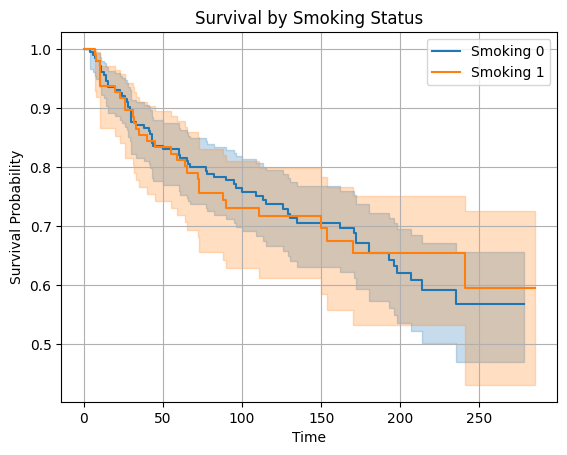

In [20]:
##--- Survival by Smoking Status ----
kmf = KaplanMeierFitter()
for group in df["smoking"].unique():

    subset = df[df["smoking"] == group]

    kmf.fit(
        subset["time"],
        subset["event"],
        label=f"Smoking {group}"
    )

    kmf.plot_survival_function()
plt.title("Survival by Smoking Status")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid()
plt.show()


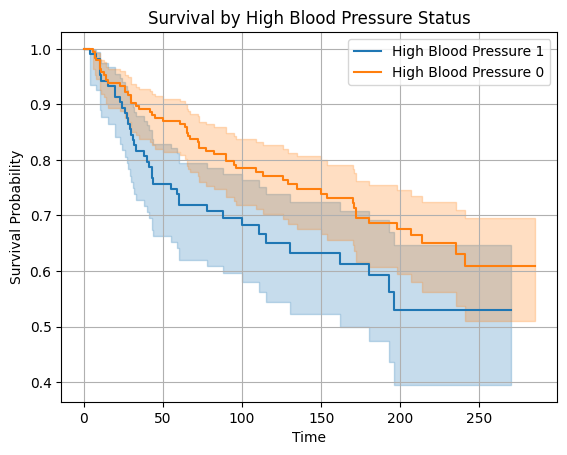

In [21]:
##--- Survival by High Blood Pressure Status ----
kmf = KaplanMeierFitter()
for group in df["high_blood_pressure"].unique():

    subset = df[df["high_blood_pressure"] == group]

    kmf.fit(
        subset["time"],
        subset["event"],
        label=f"High Blood Pressure {group}"
    )

    kmf.plot_survival_function()
plt.title("Survival by High Blood Pressure Status")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid()
plt.show()


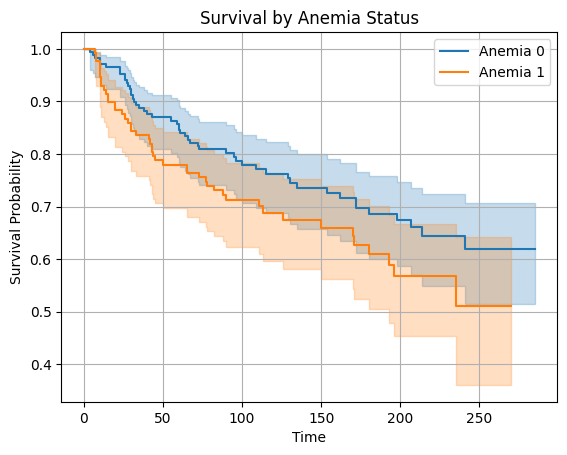

In [24]:
##--- Survival by Anemia Status ----
kmf = KaplanMeierFitter()
for group in df["anaemia"].unique():

    subset = df[df["anaemia"] == group]

    kmf.fit(
        subset["time"],
        subset["event"],
        label=f"Anemia {group}"
    )

    kmf.plot_survival_function()
plt.title("Survival by Anemia Status")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid()
plt.show()


In [ ]:
### ➡️ Strong survival difference between Anemia and No Anemia in this dataset.
### Next step is to perform log-rank test to check if the difference is statistically significant. We will cover that in the next notebook.